# Yellow Mask Detection for Parasite Identification

This notebook:
1. Processes images to detect yellow-tinted parasites using HSV color space
2. Applies morphological operations to clean up detections
3. Filters parasites by size and shape characteristics
4. Saves only images containing yellow parasites to output directory
5. Memory-efficient: processes one image at a time

In [9]:
import os
import cv2
import numpy as np
from pathlib import Path
import shutil
import matplotlib.pyplot as plt
from collections import defaultdict

## Step 1: Yellow Parasite Detection Function

In [10]:
def detect_yellow_parasites(image_path,
                            min_area=300,
                            max_area=5000):
    """
    Detect yellow-tinted parasites and return their coordinates.
    
    Args:
        image_path: Path to the image file
        min_area: Minimum contour area to consider
        max_area: Maximum contour area to consider
    
    Returns:
        boxes: list of bounding boxes (x, y, w, h)
        centroids: list of (cx, cy)
        mask: final binary mask
        has_parasites: boolean indicating if parasites were found
    """
    img = cv2.imread(str(image_path))
    if img is None:
        return [], [], None, False
    
    # Convert to HSV color space
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    
    # Define yellow color range in HSV
    lower_yellow = np.array([15, 60, 50])
    upper_yellow = np.array([35, 255, 200])
    
    # Create mask for yellow regions
    mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
    
    # Morphological operations to clean up the mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)
    
    # Find contours
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_SIMPLE)
    
    boxes = []
    centroids = []
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area or area > max_area:
            continue
        
        x, y, w, h = cv2.boundingRect(cnt)
        
        # Shape filter: elongated objects (parasites tend to be elongated)
        aspect_ratio = max(w, h) / (min(w, h) + 1e-5)
        if aspect_ratio < 1.5:
            continue
        
        cx = x + w // 2
        cy = y + h // 2
        
        boxes.append((x, y, w, h))
        centroids.append((cx, cy))
    
    has_parasites = len(boxes) > 0
    
    return boxes, centroids, mask, has_parasites




## Step 2: Process Directory and Save Images with Yellow Parasites

In [11]:
def process_directory_for_yellow_parasites(
    input_dir,
    min_area=300,
    max_area=5000
):
    """
    Process all images in a directory and save only those with yellow parasites.
    Memory-efficient: processes one image at a time.
    
    Args:
        input_dir: Path to directory containing images
        min_area: Minimum parasite area
        max_area: Maximum parasite area
        
    Returns:
        output_dir: Path to output directory
        results: List of detection results
    """
    input_path = Path(input_dir)
    parent_name = input_path.name
    parent_parent = input_path.parent
    
    # Create output directory with "yellow_" prefix
    output_dir = parent_parent / f"yellow_{parent_name}"
    output_dir.mkdir(exist_ok=True)
    
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif'}
    image_files = [f for f in input_path.iterdir()
                   if f.suffix.lower() in image_extensions]
    
    print(f"Found {len(image_files)} images in {input_dir}")
    print(f"Output directory: {output_dir}")
    print("-" * 70)
    
    images_with_parasites = 0
    total_parasites_detected = 0
    results = []
    
    for img_file in image_files:
        # Detect yellow parasites in the image
        boxes, centroids, mask, has_parasites = detect_yellow_parasites(
            img_file,
            min_area=min_area,
            max_area=max_area
        )
        
        if has_parasites:
            # Copy image to output directory
            output_path = output_dir / img_file.name
            shutil.copy(img_file, output_path)
            
            images_with_parasites += 1
            total_parasites_detected += len(boxes)
            
            results.append({
                'filename': img_file.name,
                'parasite_count': len(boxes),
                'boxes': boxes,
                'centroids': centroids
            })
            
            print(f"✓ {img_file.name:50s} | Parasites: {len(boxes)}")
        else:
            print(f"○ {img_file.name:50s} | No parasites detected")
    
    print("-" * 70)
    print(f"\n✓ Processing complete!")
    print(f"  Total images processed: {len(image_files)}")
    print(f"  Images with parasites: {images_with_parasites}")
    print(f"  Images without parasites: {len(image_files) - images_with_parasites}")
    print(f"  Total parasites detected: {total_parasites_detected}")
    print(f"  Percentage with parasites: {images_with_parasites/len(image_files)*100:.1f}%")
    print(f"\n  Output directory: {output_dir}")
    
    return output_dir, results

In [12]:
# ============================================
# CONFIGURATION
# ============================================
INPUT_DIR = "../IB_155"  # Change this to your input directory
MIN_AREA = 2500  # Minimum parasite area in pixels
MAX_AREA = 80000  # Maximum parasite area in pixels

# Process images and save those with yellow parasites
output_dir, detection_results = process_directory_for_yellow_parasites(
    INPUT_DIR,
    min_area=MIN_AREA,
    max_area=MAX_AREA
)

Found 1500 images in ../IB_155
Output directory: ../yellow_IB_155
----------------------------------------------------------------------
○ 2024-03-12_03-01-35-902515.jpg                     | No parasites detected
○ 2024-03-12_03-01-30-253678.jpg                     | No parasites detected
○ 2024-03-12_03-07-55-133220.jpg                     | No parasites detected
○ 2024-03-12_02-37-57-940257.jpg                     | No parasites detected
○ 2024-03-12_03-11-00-407036.jpg                     | No parasites detected
○ 2024-03-12_02-52-53-715894.jpg                     | No parasites detected
○ 2024-03-12_02-47-08-027357.jpg                     | No parasites detected
○ 2024-03-12_02-44-45-956314.jpg                     | No parasites detected
○ 2024-03-12_03-06-14-233295.jpg                     | No parasites detected
○ 2024-03-12_02-48-11-865413.jpg                     | No parasites detected
○ 2024-03-12_02-36-30-176951.jpg                     | No parasites detected
○ 2024-03-12_03-

## Step 3: Visualize Detection Statistics

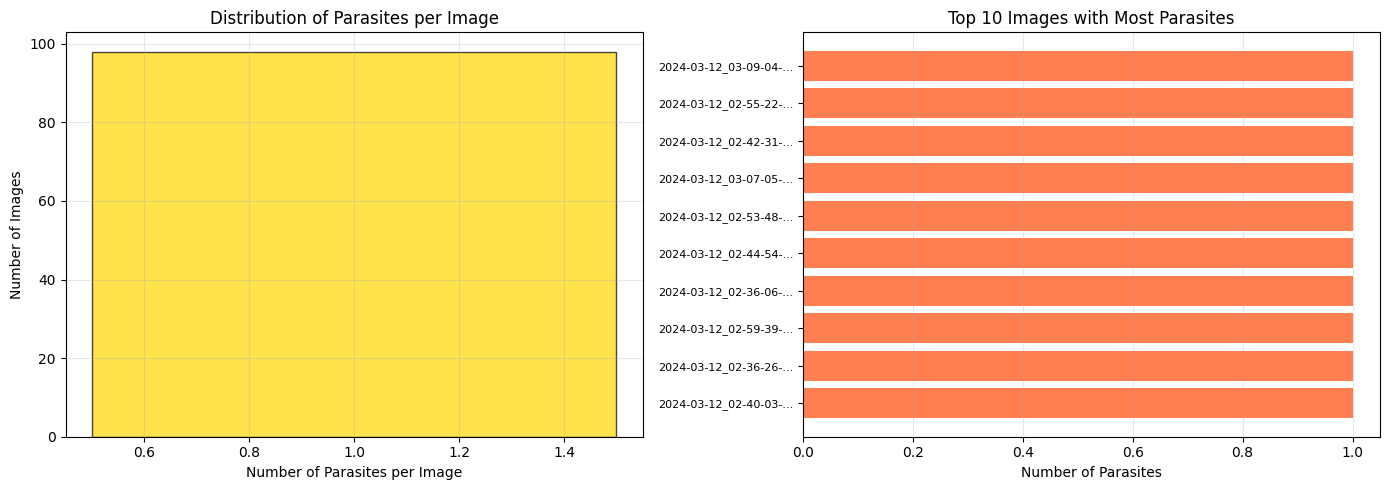


Detection Statistics:
  Total images with parasites: 98
  Average parasites per image: 1.00
  Median parasites per image: 1
  Max parasites in single image: 1
  Min parasites in detected images: 1


In [13]:


if detection_results:
    # Extract parasite counts
    parasite_counts = [r['parasite_count'] for r in detection_results]
    
    # Create visualizations
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Distribution of parasite counts
    axes[0].hist(parasite_counts, bins=max(parasite_counts), 
                 edgecolor='black', alpha=0.7, color='gold')
    axes[0].set_xlabel('Number of Parasites per Image')
    axes[0].set_ylabel('Number of Images')
    axes[0].set_title('Distribution of Parasites per Image')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Bar chart of top 10 images with most parasites
    top_10 = sorted(detection_results, key=lambda x: x['parasite_count'], reverse=True)[:10]
    filenames = [r['filename'][:20] + '...' if len(r['filename']) > 20 else r['filename'] 
                 for r in top_10]
    counts = [r['parasite_count'] for r in top_10]
    
    axes[1].barh(range(len(filenames)), counts, color='coral')
    axes[1].set_yticks(range(len(filenames)))
    axes[1].set_yticklabels(filenames, fontsize=8)
    axes[1].set_xlabel('Number of Parasites')
    axes[1].set_title('Top 10 Images with Most Parasites')
    axes[1].invert_yaxis()
    axes[1].grid(True, alpha=0.3, axis='x')
    
    plt.tight_layout()
    plt.show()
    
    print("\nDetection Statistics:")
    print(f"  Total images with parasites: {len(detection_results)}")
    print(f"  Average parasites per image: {np.mean(parasite_counts):.2f}")
    print(f"  Median parasites per image: {np.median(parasite_counts):.0f}")
    print(f"  Max parasites in single image: {max(parasite_counts)}")
    print(f"  Min parasites in detected images: {min(parasite_counts)}")
else:
    print("No parasites detected in any images.")

## Optional: Visualize Sample Detections

View images with detected parasites and their bounding boxes

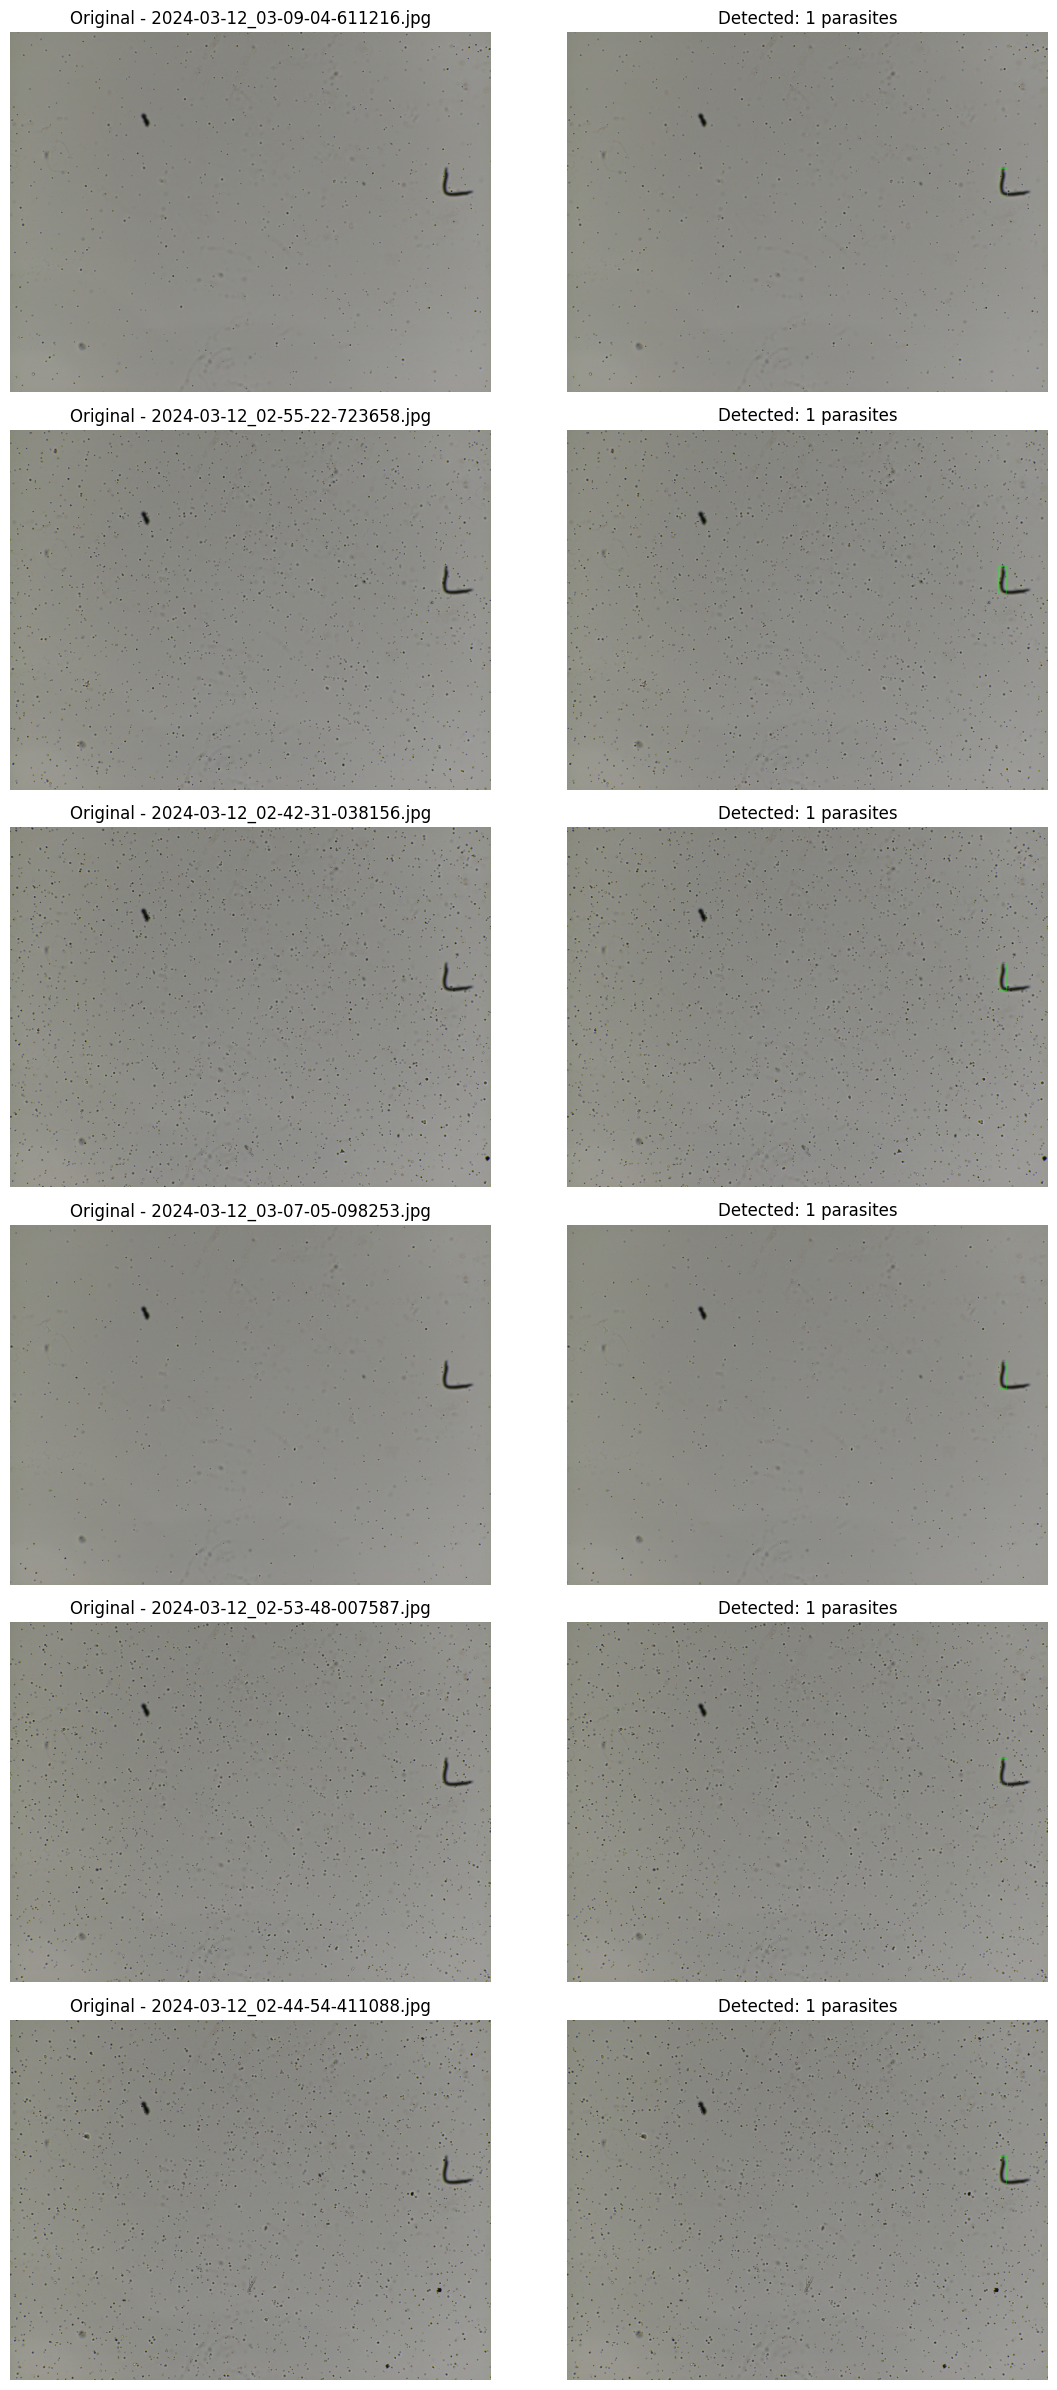

Showing top 6 images with most parasites


In [14]:
if detection_results:
    # Select top 6 images with most parasites
    top_images = sorted(detection_results, key=lambda x: x['parasite_count'], reverse=True)[:6]
    
    num_images = len(top_images)
    fig, axes = plt.subplots(num_images, 2, figsize=(12, 4*num_images))
    
    # Handle case where there's only one image
    if num_images == 1:
        axes = axes.reshape(1, -1)
    
    for idx, result in enumerate(top_images):
        # Read original image
        img_path = Path(output_dir) / result['filename']
        img = cv2.imread(str(img_path))
        
        if img is None:
            continue
        
        # Create annotated version
        img_annotated = img.copy()
        
        # Draw bounding boxes and centroids
        for (x, y, w, h), (cx, cy) in zip(result['boxes'], result['centroids']):
            cv2.rectangle(img_annotated, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.circle(img_annotated, (cx, cy), 3, (0, 0, 255), -1)
        
        # Convert BGR to RGB for matplotlib
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_annotated_rgb = cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB)
        
        # Display original
        axes[idx, 0].imshow(img_rgb)
        axes[idx, 0].set_title(f"Original - {result['filename'][:30]}")
        axes[idx, 0].axis('off')
        
        # Display with detections
        axes[idx, 1].imshow(img_annotated_rgb)
        axes[idx, 1].set_title(f"Detected: {result['parasite_count']} parasites")
        axes[idx, 1].axis('off')
        
        # Free memory
        del img, img_annotated, img_rgb, img_annotated_rgb
    
    plt.tight_layout()
    plt.show()
    
    print(f"Showing top {num_images} images with most parasites")
else:
    print("No detections to visualize.")

## Optional: Fine-tune Detection Parameters

Adjust HSV ranges and size constraints if needed

In [15]:
# Test detection on a single image with different parameters
test_image_path = Path(INPUT_DIR) / "2024-03-12_01-22-12-044496.jpg"  # Change to your test image

if test_image_path.exists():
    # Try different parameter combinations
    parameter_sets = [
        {"min_area": 200, "max_area": 5000, "label": "Smaller min (200)"},
        {"min_area": 300, "max_area": 5000, "label": "Default (300)"},
        {"min_area": 500, "max_area": 5000, "label": "Larger min (500)"},
    ]
    
    fig, axes = plt.subplots(1, len(parameter_sets), figsize=(15, 5))
    
    for idx, params in enumerate(parameter_sets):
        boxes, centroids, mask, has_parasites = detect_yellow_parasites(
            test_image_path,
            min_area=params["min_area"],
            max_area=params["max_area"]
        )
        
        img = cv2.imread(str(test_image_path))
        img_annotated = img.copy()
        
        # Draw detections
        for (x, y, w, h), (cx, cy) in zip(boxes, centroids):
            cv2.rectangle(img_annotated, (x, y), (x+w, y+h), (0, 255, 0), 2)
            cv2.circle(img_annotated, (cx, cy), 3, (0, 0, 255), -1)
        
        img_rgb = cv2.cvtColor(img_annotated, cv2.COLOR_BGR2RGB)
        
        axes[idx].imshow(img_rgb)
        axes[idx].set_title(f"{params['label']}\nDetected: {len(boxes)}")
        axes[idx].axis('off')
        
        del img, img_annotated, img_rgb
    
    plt.tight_layout()
    plt.show()
    
    print("\nParameter tuning guide:")
    print("  - Decrease min_area to detect smaller parasites")
    print("  - Increase min_area to filter out noise")
    print("  - Adjust HSV ranges in the function for different yellow shades")
else:
    print(f"Test image not found: {test_image_path}")

Test image not found: ../IB_155/2024-03-12_01-22-12-044496.jpg
